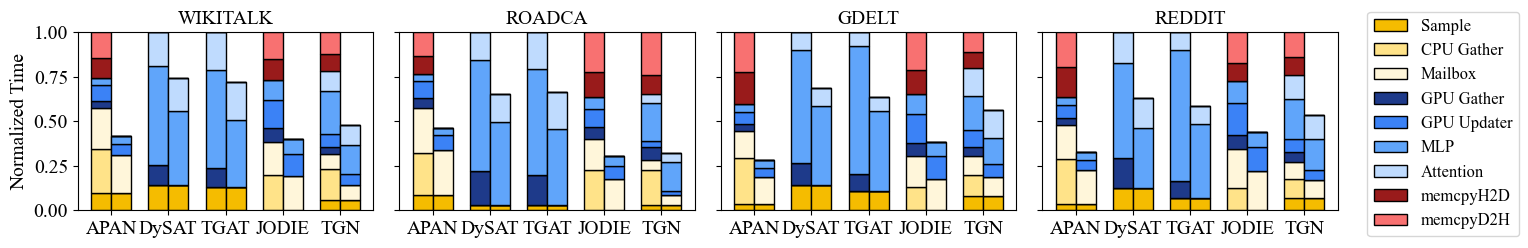

In [1]:
import yaml
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=14)
plt.rc('axes', titlesize=14)
# 读取 YAML 文件
with open('total.yaml', 'r') as file:
    data = yaml.safe_load(file)

def normalize_data(data):
    normalized_data = {}
    for model, experiments in data.items():
        normalized_data[model] = {}
        for experiment, components in experiments.items():
            normalized_data[model][experiment] = {}
            
            # Get the sum of 'MSPipe' components
            ms_pipe_sum = sum(components['MSPipe'].values())
            
            # Normalize 'MSPipe' components
            normalized_data[model][experiment]['MSPipe'] = {
                key: value / ms_pipe_sum for key, value in components['MSPipe'].items()
            }
            
            # Normalize 'UNITY' components based on 'MSPipe' sum
            normalized_data[model][experiment]['UNITY'] = {
                key: value / ms_pipe_sum for key, value in components['UNITY'].items()
            }
            
            # Keep 'TGL' components unchanged
            normalized_data[model][experiment]['TGL'] = components['TGL']
    
    return normalized_data

# Call the function to normalize the data
normalized_data = normalize_data(data)

# 颜色设置
# colors = ["#2A9790", "#876D4C", "#91A1A3", "#5183AC", "#CDAC59", "#CF5785", "#E38B43", "#D8BFAA", "#C8755E"]
# colors = ["#FFFF99", "#FDBF6F", "#B2DF8A", "#A6CEE3", "#CAB2D6", "#FB9A99", "#D9D9D9", "#7F7F7F", "#000000"]

cpu = ["#FFD700", "#FFEB7B", "#FFF8C6"]  # Yellow
gpu = ["#1E3A8A", "#3B82F6", "#60A5FA", "#BFDBFE"]  # Blue
transfer = ["#991B1B", "#F87171"]  # Red
colors = ["#F5BC00", "#FFe389", "#FFF6da","#1E3A8A", "#3B82F6", "#60A5FA", "#BFDBFE","#991B1B", "#F87171"]
# 数据集、方法、模型等
datasets = ["WIKITALK", "ROADCA", "GDELT", "REDDIT"]
methods = ["APAN", "DySAT", "TGAT", "JODIE", "TGN"]
models = ["MSPipe", "UNITY"]

# 获取所有的成分类别（去重排序）
preferred_order = [
    "Sample", "CPU Gather", "Mailbox", "GPU Gather", "GPU Updater", "MLP", "Attention", "memcpyH2D", "memcpyD2H"
]

all_components = sorted({
    component
    for dataset in datasets
    for method in methods
    for model in models
    if model in data[dataset].get(method, {})
    for component in data[dataset][method][model]
}, key=lambda x: preferred_order.index(x) if x in preferred_order else len(preferred_order))

# 创建一个共享y轴的4个子图
fig, axes = plt.subplots(1, 4, figsize=(16, 2.7), sharey=True)

# 存储 legend 显示的句柄
legend_handles = []
# hatch_components = ["Sample", "Mailbox", "Memory Update", "CPU Gather", "H2D", "D2H"]
# 遍历数据集
for i, dataset in enumerate(datasets):
    ax = axes[i]
    
    bar_width = 0.35  # 柱状图宽度
    indices = np.array([0, 1, 2, 3, 4])  # TGN 和 TGAT 的位置
    
    # 初始化堆叠底部
    bottom_tgl = np.zeros(len(methods))
    bottom_unity = np.zeros(len(methods))

    for j, component in enumerate(all_components):
        tgl_values = [
            normalized_data[dataset].get(method, {}).get("MSPipe", {}).get(component, 0) for method in methods
        ]
        unity_values = [
            normalized_data[dataset].get(method, {}).get("UNITY", {}).get(component, 0) for method in methods
        ]
        hatch = None
        # if component in hatch_components:
        #     hatch = "///"  # 设置阴影样式

        # 画 TGL
        bar_tgl = ax.bar(indices - bar_width / 2, tgl_values, bar_width, color=colors[j], bottom=bottom_tgl, edgecolor='black', hatch=hatch)
        # 画 UNITY
        bar_unity = ax.bar(indices + bar_width / 2, unity_values, bar_width, color=colors[j], bottom=bottom_unity, edgecolor='black', hatch=hatch)

        # 记录 legend 句柄，仅在第一个子图存储一次
        if i == 0:
            legend_handles.append((bar_tgl[0], component))

        # 叠加底部
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)
        bottom_tgl += np.array(tgl_values)
        bottom_unity += np.array(unity_values)

    ax.set_xticks(indices)
    ax.set_xticklabels(methods)
    ax.set_title(dataset)

# 设置 y 轴标签
axes[0].set_ylabel("Normalized Time")

# 总标题

# 图例放置在右侧
legend_labels = [label for _, label in legend_handles]
legend_patches = [patch for patch, _ in legend_handles]
fig.legend(legend_patches, legend_labels, loc="center left", bbox_to_anchor=(0.85, 0.5), fontsize=12)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('exp5.pdf', bbox_inches='tight')
plt.show()
